# 🔄 Customer Churn Prediction
### End-to-End Machine Learning Project

**Dataset:** IBM Telco Customer Churn  
**Goal:** Predict whether a customer will churn (leave the service)  
**Pipeline:** EDA → Preprocessing → SMOTE → Model Comparison → Hyperparameter Tuning → Evaluation → Deployment-Ready Predictor

---

## 1. 📦 Importing Dependencies

In [33]:
# Install required packages
!pip install xgboost imbalanced-learn --quiet
!pip install streamlit pandas scikit-learn xgboost

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import pickle

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 2. 📂 Data Loading & Understanding

In [13]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

Dataset Shape: (7043, 21)
Rows: 7,043 | Columns: 21


In [14]:
pd.set_option('display.max_columns', None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [16]:
# Drop CustomerID - irrelevant for modeling
df = df.drop(columns=['customerID'])

# Check class distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print('=== Target Variable Distribution ===')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))
print(f'\n⚠️  Class Imbalance Ratio: {churn_counts[0]/churn_counts[1]:.2f}:1 (No Churn : Churn)')

=== Target Variable Distribution ===
       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54

⚠️  Class Imbalance Ratio: 2.77:1 (No Churn : Churn)


## 3. 🔍 Data Cleaning

In [17]:
# Fix TotalCharges - has whitespace as values for new customers
print('Missing / blank TotalCharges entries:', len(df[df['TotalCharges'] == ' ']))

df['TotalCharges'] = df['TotalCharges'].replace({' ': '0.0'})
df['TotalCharges'] = df['TotalCharges'].astype(float)

# Final null check
null_counts = df.isnull().sum()
print('\n=== Null Values After Cleaning ===')
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else '✅ No missing values!')

Missing / blank TotalCharges entries: 11

=== Null Values After Cleaning ===
✅ No missing values!


## 4. 📊 Exploratory Data Analysis (EDA)

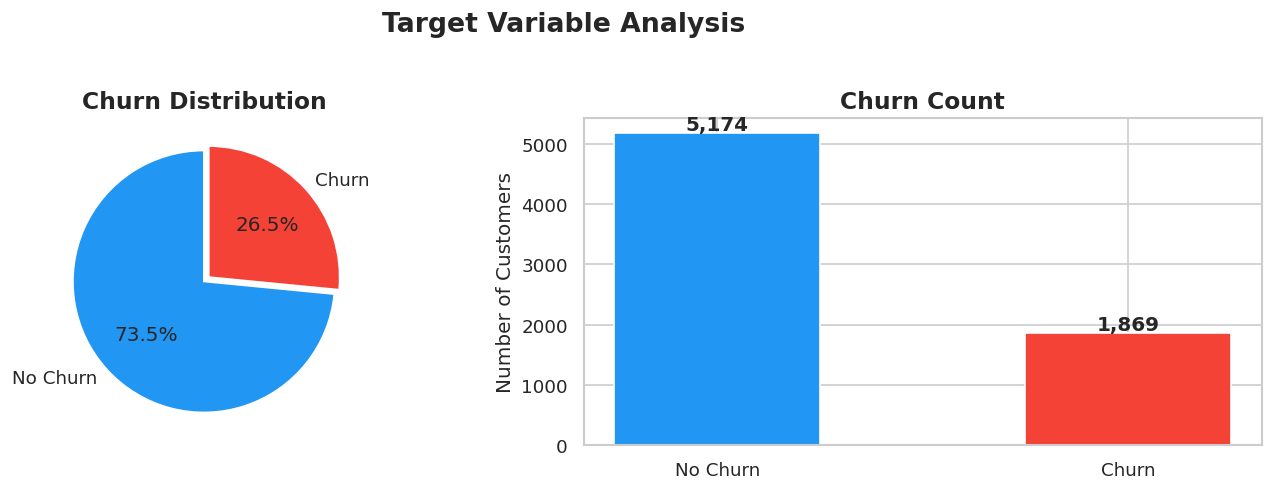

In [18]:
# === 4.1 Churn Distribution Pie Chart ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(
    churn_counts, labels=['No Churn', 'Churn'],
    autopct='%1.1f%%', startangle=90,
    colors=['#2196F3', '#F44336'], explode=(0, 0.05)
)
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(['No Churn', 'Churn'], churn_counts, color=['#2196F3', '#F44336'], width=0.5)
for bar, count in zip(bars, churn_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', fontweight='bold')
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

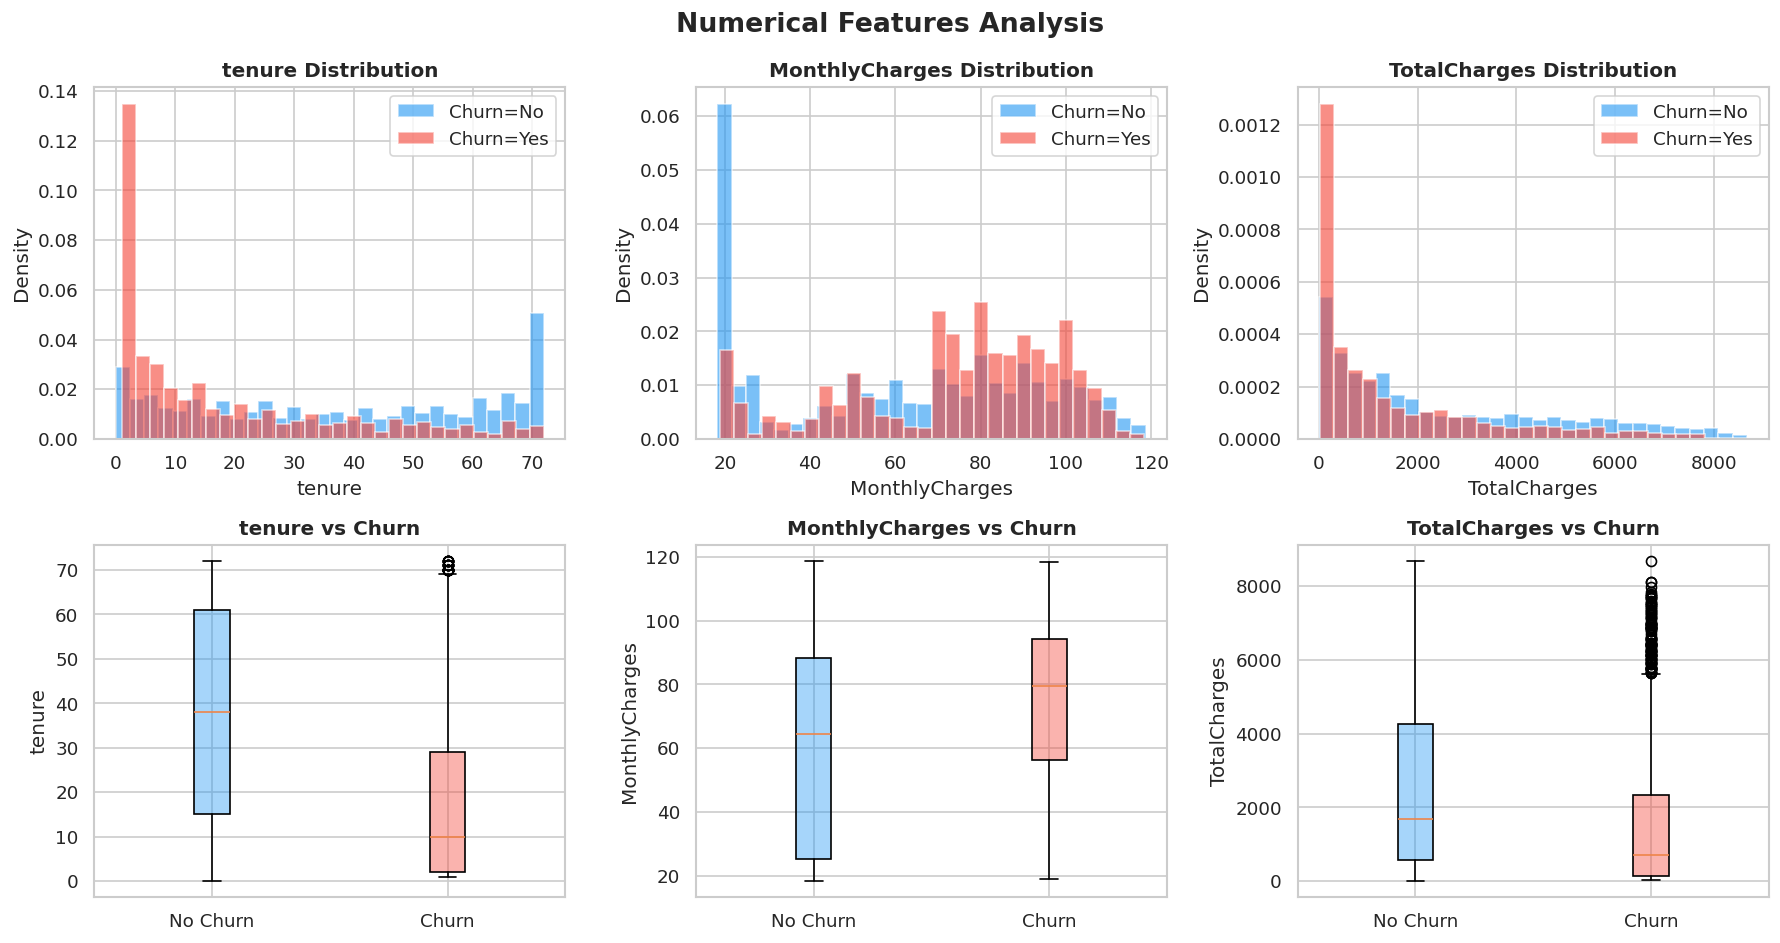

In [19]:
# === 4.2 Numerical Features - Distribution by Churn ===
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(numerical_cols):
    # Distribution plot
    ax = axes[0, i]
    for label, color in [('No', '#2196F3'), ('Yes', '#F44336')]:
        subset = df[df['Churn'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}', density=True)
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.legend()
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

    # Boxplot by churn
    ax2 = axes[1, i]
    churn_data = [df[df['Churn'] == 'No'][col], df[df['Churn'] == 'Yes'][col]]
    bp = ax2.boxplot(churn_data, labels=['No Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2196F366')
    bp['boxes'][1].set_facecolor('#F4433666')
    ax2.set_title(f'{col} vs Churn', fontweight='bold')
    ax2.set_ylabel(col)

plt.suptitle('Numerical Features Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

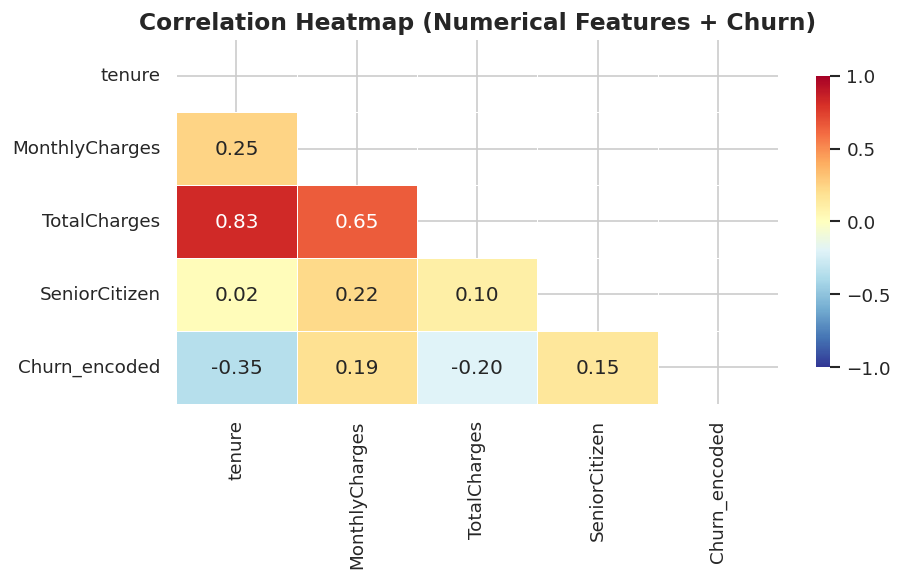

In [20]:
# === 4.3 Correlation Heatmap ===
plt.figure(figsize=(8, 5))
# Encode churn temporarily
temp_df = df.copy()
temp_df['Churn_encoded'] = (temp_df['Churn'] == 'Yes').astype(int)
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_encoded']
corr = temp_df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap (Numerical Features + Churn)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

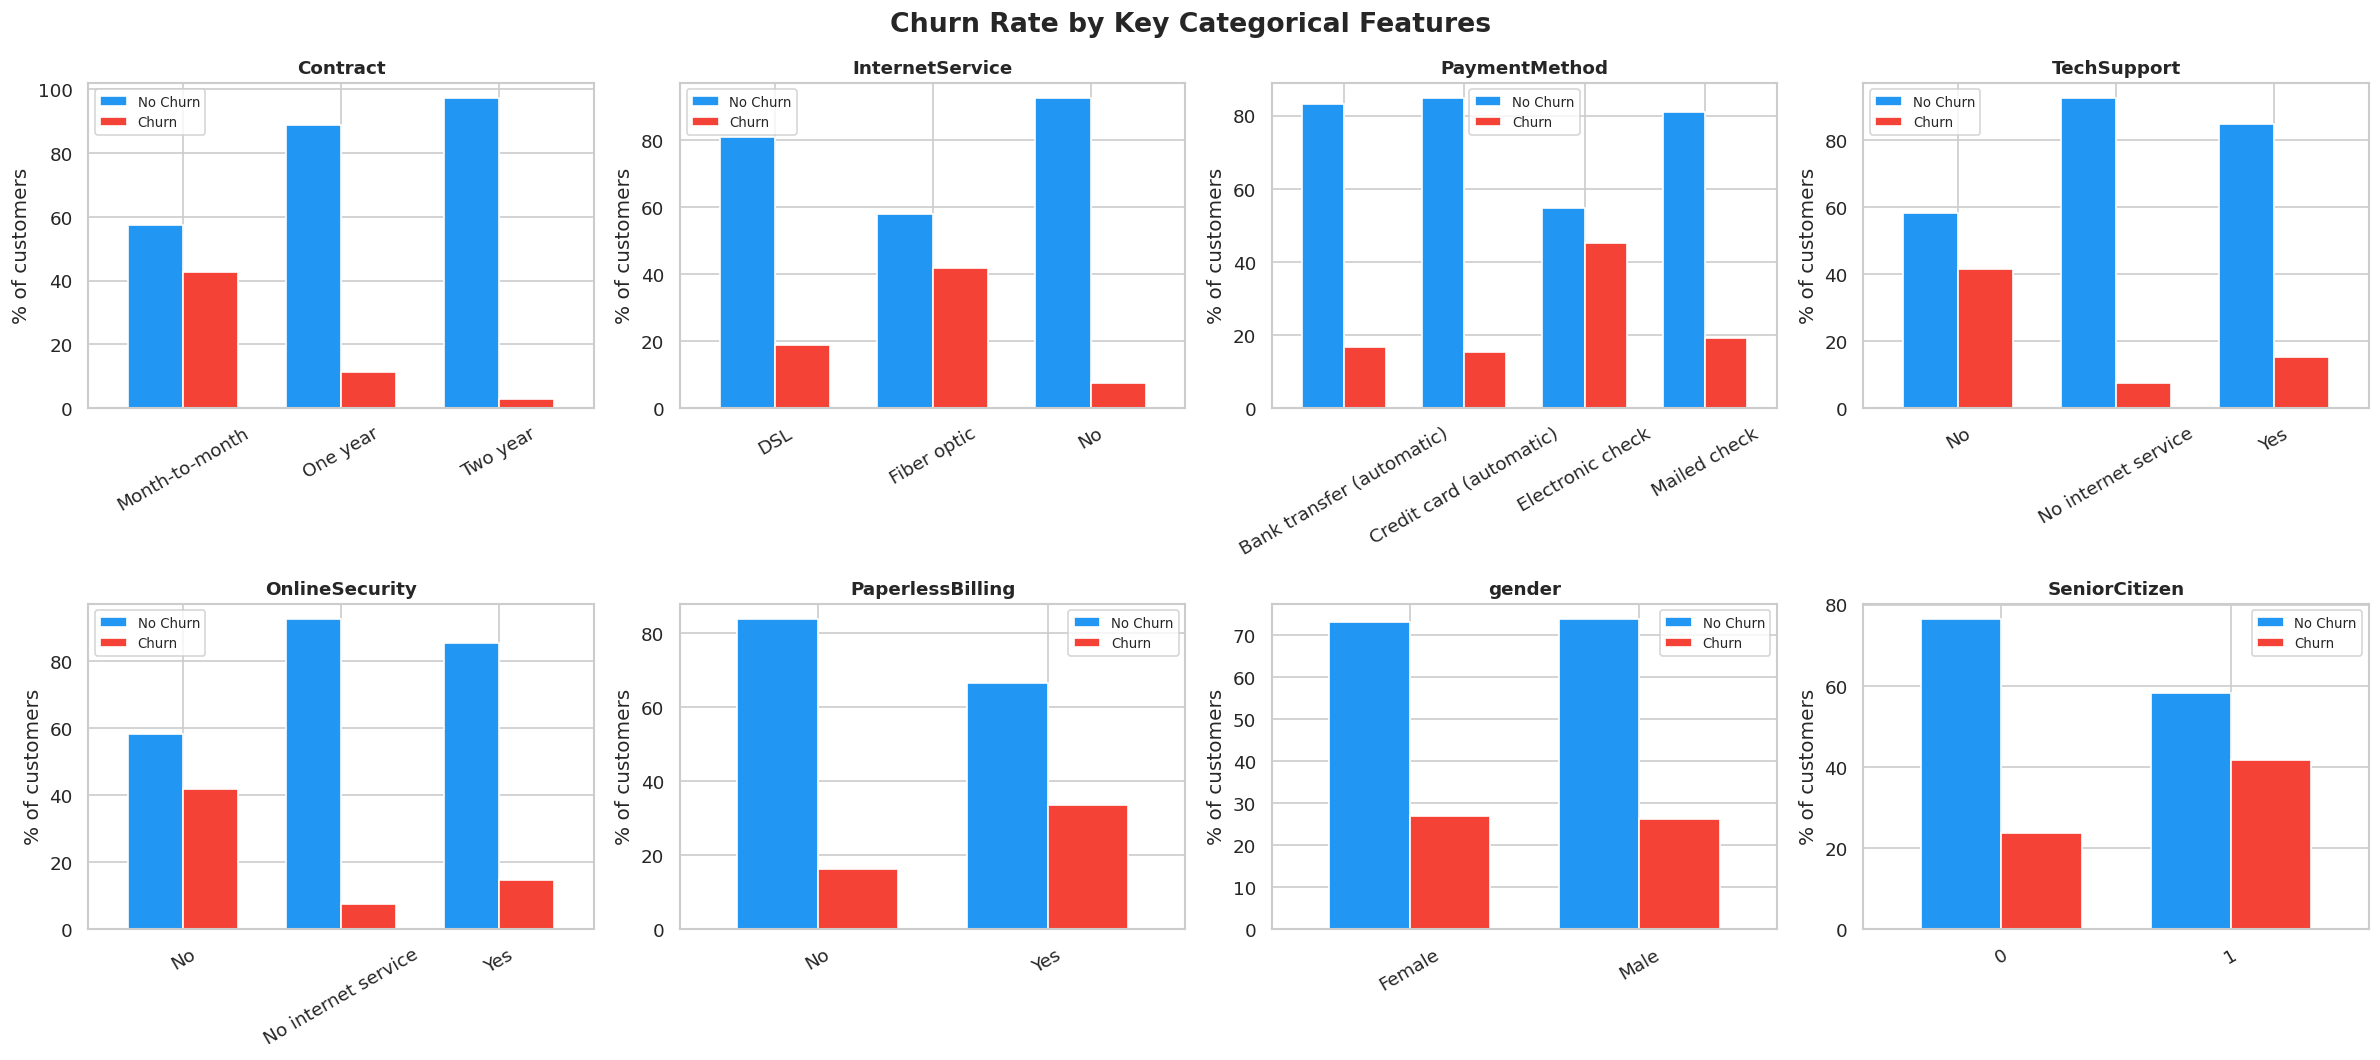

📌 Key Insight: Month-to-month contract, no tech support, and electronic check payment
   are strongly associated with higher churn rates.


In [21]:
# === 4.4 Key Categorical Features vs Churn ===
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport',
            'OnlineSecurity', 'PaperlessBilling', 'gender', 'SeniorCitizen']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2196F3', '#F44336'],
            edgecolor='white', width=0.7)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% of customers')
    axes[i].legend(['No Churn', 'Churn'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('📌 Key Insight: Month-to-month contract, no tech support, and electronic check payment\n   are strongly associated with higher churn rates.')

## 5. 🔧 Data Preprocessing

In [22]:
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Label encode all object columns & save encoders
object_columns = df.select_dtypes(include='object').columns
print(f'Encoding {len(object_columns)} categorical columns: {list(object_columns)}')

encoders = {}
for col in object_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print('\n✅ Encoding complete. Encoders saved to encoders.pkl')
df.head(3)

Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ Encoding complete. Encoders saved to encoders.pkl


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


In [23]:
# Train-test split (stratified to preserve class ratio)
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape[0]:,} samples | Test set: {X_test.shape[0]:,} samples')
print(f'Train churn rate: {y_train.mean()*100:.1f}% | Test churn rate: {y_test.mean()*100:.1f}%')

Train set: 5,634 samples | Test set: 1,409 samples
Train churn rate: 26.5% | Test churn rate: 26.5%


Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


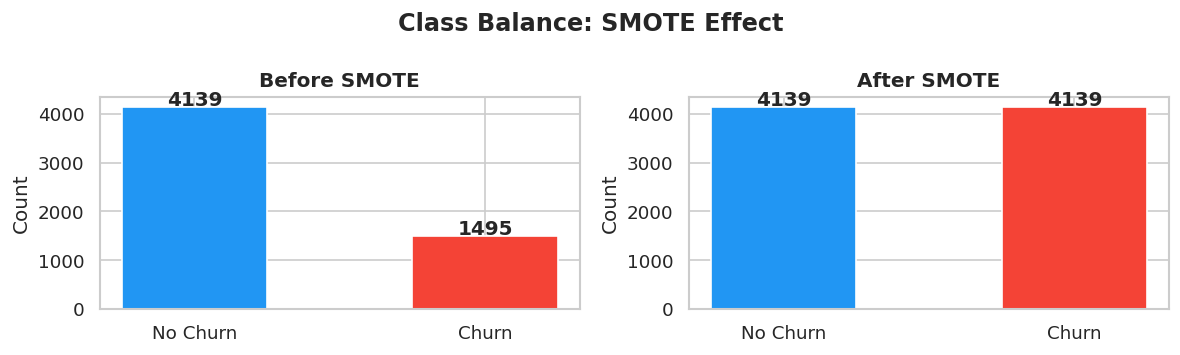

In [24]:
# Apply SMOTE to handle class imbalance
print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE: ', dict(zip(*np.unique(y_train_sm, return_counts=True))))

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, data, title in zip(axes, [y_train, y_train_sm], ['Before SMOTE', 'After SMOTE']):
    counts = np.bincount(data)
    ax.bar(['No Churn', 'Churn'], counts, color=['#2196F3', '#F44336'], width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for j, c in enumerate(counts):
        ax.text(j, c + 30, str(c), ha='center', fontweight='bold')
plt.suptitle('Class Balance: SMOTE Effect', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. 🤖 Model Training & Comparison

In [25]:
# === 6.1 Cross-Validation Comparison (5 Models) ===
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold cross-validation...\n')
for name, model in models.items():
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  Acc: {scores.mean():.4f} ± {scores.std():.4f}')

Running 5-fold cross-validation...

Logistic Regression        Acc: 0.8037 ± 0.0073
Decision Tree              Acc: 0.7868 ± 0.0085
Random Forest              Acc: 0.8507 ± 0.0060
Gradient Boosting          Acc: 0.8322 ± 0.0066
XGBoost                    Acc: 0.8484 ± 0.0071


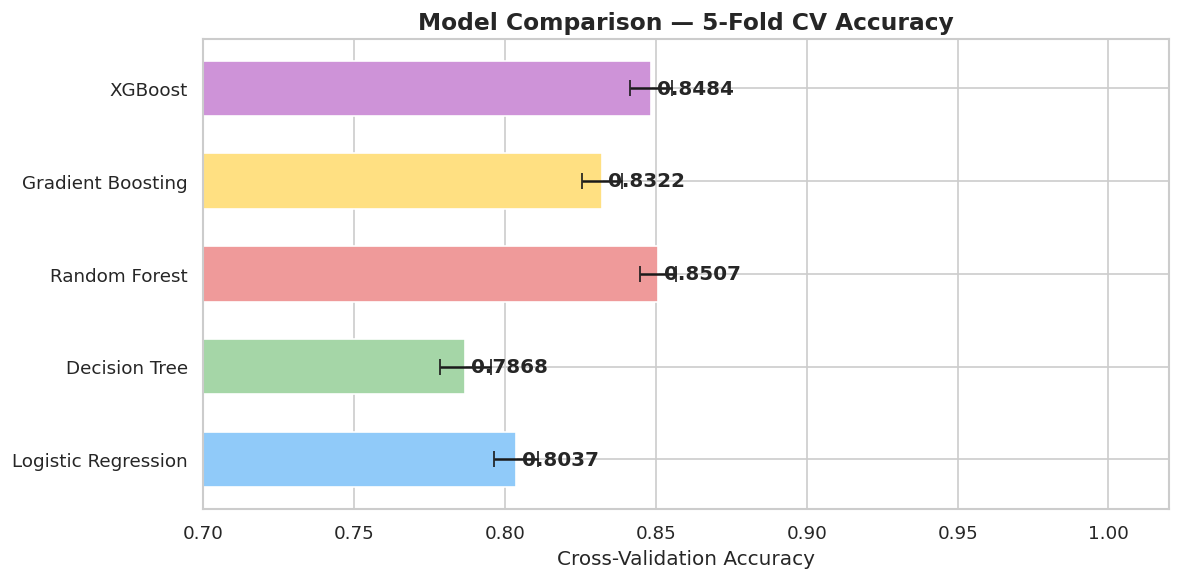

In [26]:
# === 6.2 CV Results Visualization ===
fig, ax = plt.subplots(figsize=(10, 5))

names = list(cv_results.keys())
means = [v.mean() for v in cv_results.values()]
stds  = [v.std()  for v in cv_results.values()]

colors = ['#90CAF9', '#A5D6A7', '#EF9A9A', '#FFE082', '#CE93D8']
bars = ax.barh(names, means, xerr=stds, color=colors, edgecolor='white',
               capsize=5, height=0.6)
ax.set_xlabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title('Model Comparison — 5-Fold CV Accuracy', fontsize=14, fontweight='bold')
ax.set_xlim(0.7, 1.02)
for bar, mean in zip(bars, means):
    ax.text(mean + 0.002, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. ⚙️ Hyperparameter Tuning (Random Forest)

In [27]:
# GridSearchCV on Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_sm, y_train_sm)

print(f'\n✅ Best Parameters: {grid_search.best_params_}')
print(f'Best CV F1 Score:  {grid_search.best_score_:.4f}')

best_rfc = grid_search.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score:  0.8081


## 8. 📈 Model Evaluation

In [28]:
# Predictions
y_pred      = best_rfc.predict(X_test)
y_pred_prob = best_rfc.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_pred_prob)
f1   = f1_score(y_test, y_pred)

print('=' * 45)
print(f'  Accuracy :  {acc:.4f}')
print(f'  ROC-AUC  :  {auc:.4f}')
print(f'  F1 Score :  {f1:.4f}')
print('=' * 45)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

  Accuracy :  0.7708
  ROC-AUC  :  0.8326
  F1 Score :  0.6132

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.56      0.68      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.77      0.78      1409



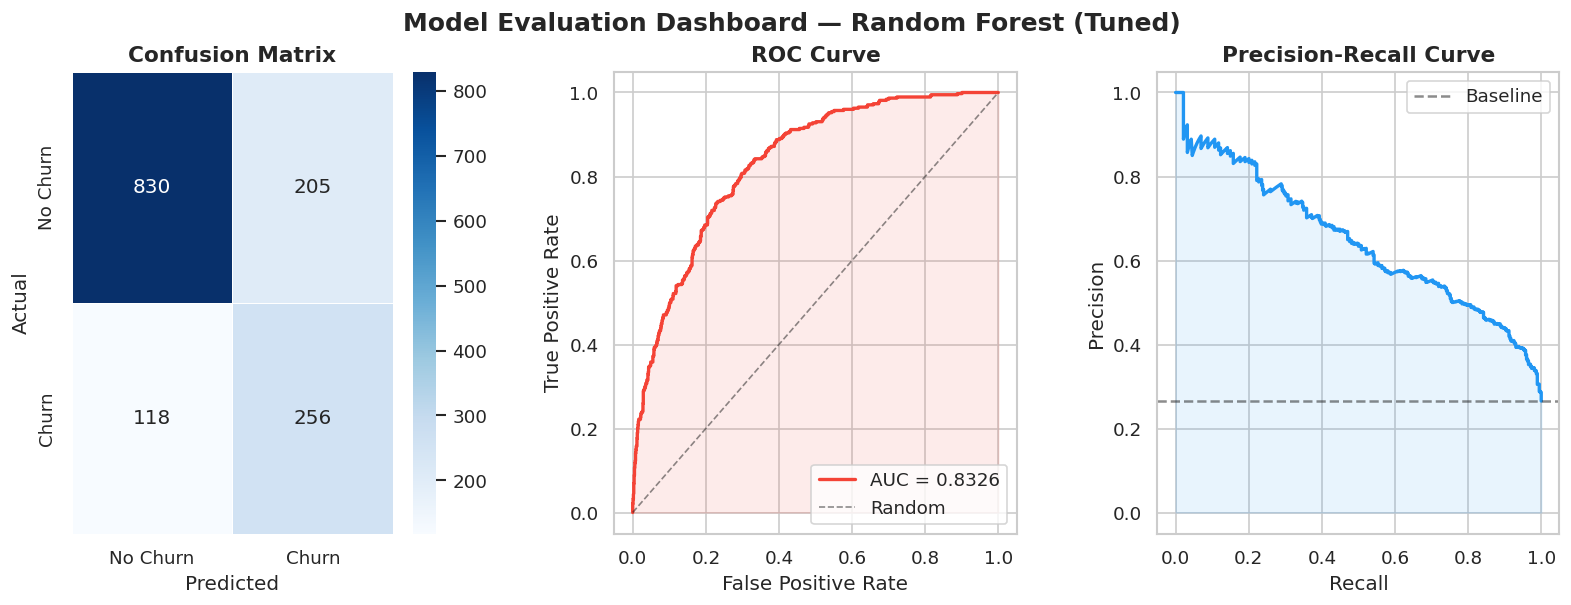

In [29]:
# === Comprehensive Evaluation Dashboard ===
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Confusion Matrix ---
ax1 = fig.add_subplot(gs[0])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], linewidths=0.5)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# --- ROC Curve ---
ax2 = fig.add_subplot(gs[1])
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr, color='#F44336', lw=2, label=f'AUC = {auc:.4f}')
ax2.plot([0,1], [0,1], 'k--', lw=1, alpha=0.5, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#F44336')
ax2.set_xlabel('False Positive Rate'); ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold', fontsize=13)
ax2.legend(loc='lower right')

# --- Precision-Recall Curve ---
ax3 = fig.add_subplot(gs[2])
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
ax3.plot(recall, precision, color='#2196F3', lw=2)
ax3.fill_between(recall, precision, alpha=0.1, color='#2196F3')
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
ax3.axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label='Baseline')
ax3.legend()

plt.suptitle('Model Evaluation Dashboard — Random Forest (Tuned)', fontsize=15, fontweight='bold')
plt.show()

## 9. 🔑 Feature Importance Analysis

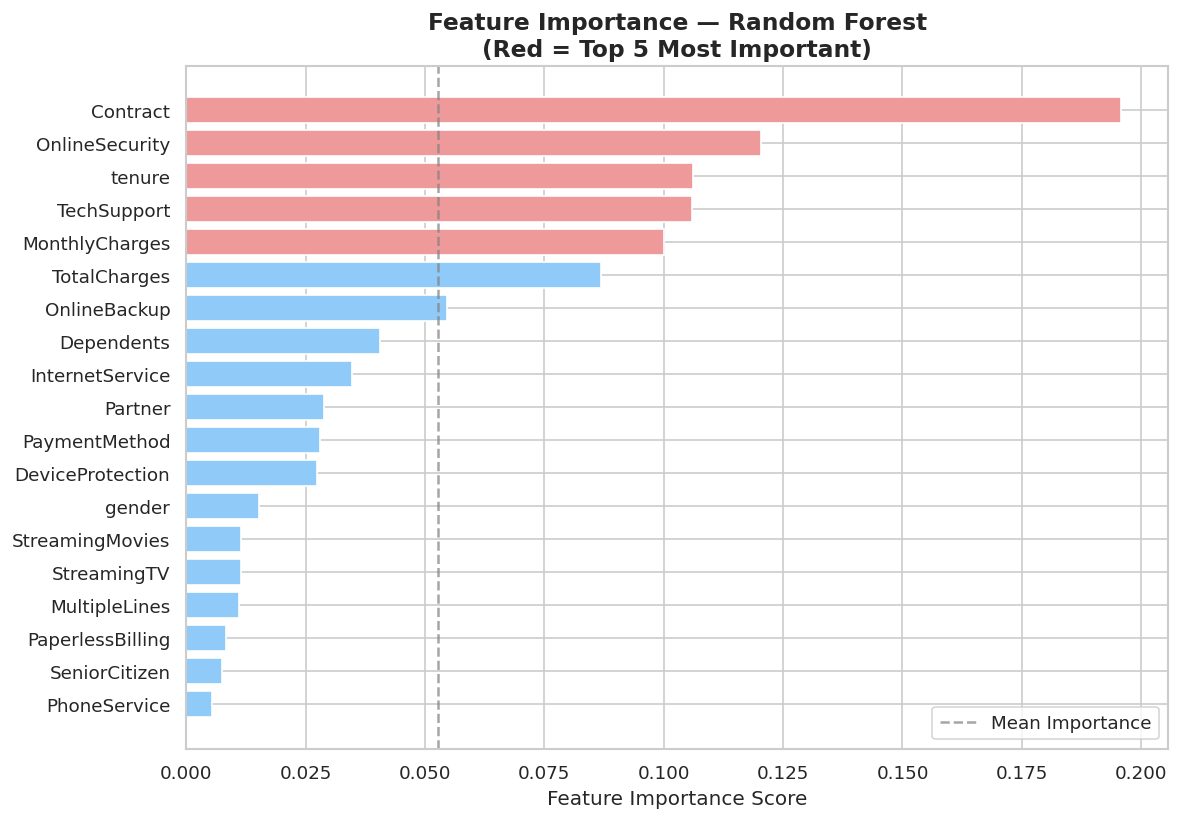


🏆 Top 5 Most Important Features:
                Importance
Contract          0.195848
OnlineSecurity    0.120425
tenure            0.106084
TechSupport       0.105825
MonthlyCharges    0.100123


In [30]:
# Feature Importance from Random Forest
feat_imp = pd.Series(best_rfc.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

# Color top 5 differently
colors = ['#EF9A9A' if i >= len(feat_imp)-5 else '#90CAF9' for i in range(len(feat_imp))]

plt.figure(figsize=(10, 7))
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest\n(Red = Top 5 Most Important)', 
          fontsize=14, fontweight='bold')
plt.axvline(feat_imp.mean(), color='gray', linestyle='--', alpha=0.7, label='Mean Importance')
plt.legend()
plt.tight_layout()
plt.show()

print('\n🏆 Top 5 Most Important Features:')
print(feat_imp.tail(5).sort_values(ascending=False).to_frame('Importance').to_string())

## 10. 💾 Save Model

In [31]:
model_data = {
    'model': best_rfc,
    'feature_names': X.columns.tolist(),
    'metrics': {
        'accuracy': round(acc, 4),
        'roc_auc': round(auc, 4),
        'f1_score': round(f1, 4)
    }
}

with open('customer_churn_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('✅ Model saved: customer_churn_model.pkl')
print(f'   Accuracy:  {acc:.4f}')
print(f'   ROC-AUC:   {auc:.4f}')
print(f'   F1 Score:  {f1:.4f}')

✅ Model saved: customer_churn_model.pkl
   Accuracy:  0.7708
   ROC-AUC:   0.8326
   F1 Score:  0.6132


## 11. 🔮 Predictive System

In [32]:
def predict_churn(customer_data: dict) -> dict:
    """
    Predict churn for a new customer.
    
    Parameters:
        customer_data (dict): Customer feature dictionary
    Returns:
        dict: prediction, probability, and risk level
    """
    # Load model & encoders
    with open('customer_churn_model.pkl', 'rb') as f:
        model_data = pickle.load(f)
    with open('encoders.pkl', 'rb') as f:
        encoders = pickle.load(f)

    model = model_data['model']

    # Prepare input
    input_df = pd.DataFrame([customer_data])

    # Encode categorical columns
    for col, encoder in encoders.items():
        if col in input_df.columns:
            input_df[col] = encoder.transform(input_df[col])

    # Predict
    prediction = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]

    risk = 'HIGH' if prob > 0.7 else ('MEDIUM' if prob > 0.4 else 'LOW')

    return {
        'prediction': 'CHURN' if prediction == 1 else 'NO CHURN',
        'churn_probability': round(prob * 100, 2),
        'risk_level': risk
    }


# ===  Test the predictor ===
customer_1 = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
    'tenure': 1, 'PhoneService': 'No', 'MultipleLines': 'No phone service',
    'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No',
    'StreamingMovies': 'No', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 29.85, 'TotalCharges': 29.85
}

customer_2 = {
    'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
    'tenure': 60, 'PhoneService': 'Yes', 'MultipleLines': 'Yes',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes', 'TechSupport': 'Yes', 'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes', 'Contract': 'Two year', 'PaperlessBilling': 'No',
    'PaymentMethod': 'Bank transfer (automatic)', 'MonthlyCharges': 99.65, 'TotalCharges': 5987.0
}

for i, customer in enumerate([customer_1, customer_2], 1):
    result = predict_churn(customer)
    print(f'Customer {i}: {result["prediction"]} | Probability: {result["churn_probability"]}% | Risk: {result["risk_level"]}')

Customer 1: NO CHURN | Probability: 46.19% | Risk: MEDIUM
Customer 2: NO CHURN | Probability: 8.62% | Risk: LOW


## 12. 📝 Project Summary

| Step | Detail |
|------|--------|
| **Dataset** | IBM Telco — 7,043 customers, 20 features |
| **Target** | Binary: Churn / No Churn (~26.5% churn rate) |
| **Imbalance Handling** | SMOTE applied on training set only |
| **Models Compared** | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost |
| **Best Model** | Random Forest (GridSearchCV tuned) |
| **Evaluation Metrics** | Accuracy, F1, ROC-AUC, Confusion Matrix, PR Curve |
| **Key Churning Signals** | Short tenure, Month-to-month contract, Electronic check payment, No TechSupport |
| **Deliverables** | Trained model (.pkl), encoders (.pkl), predictor function |

### ✅ Skills Demonstrated
- Data cleaning and EDA with business insights
- Handling class imbalance with SMOTE
- Multi-model comparison with cross-validation
- Hyperparameter tuning with GridSearchCV
- Comprehensive evaluation (Accuracy, AUC, F1, Confusion Matrix, PR Curve)
- Feature importance analysis
- Deployment-ready predictive function with risk scoring